In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GridSearchCV, StratifiedGroupKFold, cross_val_score
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import optuna

/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
filePath = "/Users/pritibhunia/repos/medium-voltage-cable/Real Data/PD_complete.csv"
data = pd.read_csv(filePath, delimiter=';')
data.dropna(inplace=True)
print(data.head())


   cable_id  meas_id  plan_id  pd_id  line_nr  nr_voltage_steps  pd_nr  \
0         1        1        1      1        1                 2      1   
1         2        2        4      4        1                 2      1   
2         2        2        4      4        1                 2      4   
3         2        2        4      4        1                 2      2   
4         2        2        4      4        1                 2      3   

   pd_distance_m  max_pd_pc  voltage_step_factor pd_cable_or_connection_type  \
0           5063      850.0                  1.8                   VPE-Kabel   
1              5      620.0                  1.7          Papier-Masse-Kabel   
2            212      820.0                  1.7          Papier-Masse-Kabel   
3             55      580.0                  1.7          Papier-Masse-Kabel   
4            143      520.0                  1.7          Papier-Masse-Kabel   

      pd_distribution pd_assessment_category    cable_type  
0            

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cable_id                     376 non-null    int64  
 1   meas_id                      376 non-null    int64  
 2   plan_id                      376 non-null    int64  
 3   pd_id                        376 non-null    int64  
 4   line_nr                      376 non-null    int64  
 5   nr_voltage_steps             376 non-null    int64  
 6   pd_nr                        376 non-null    int64  
 7   pd_distance_m                376 non-null    int64  
 8   max_pd_pc                    376 non-null    float64
 9   voltage_step_factor          376 non-null    float64
 10  pd_cable_or_connection_type  376 non-null    object 
 11  pd_distribution              376 non-null    object 
 12  pd_assessment_category       376 non-null    object 
 13  cable_type          

In [4]:
data

,cable_id,meas_id,plan_id,pd_id,line_nr,nr_voltage_steps,pd_nr,pd_distance_m,max_pd_pc,voltage_step_factor,pd_cable_or_connection_type,pd_distribution,pd_assessment_category,cable_type
0,1,1,1,1,1,2,1,5063,850.0,1.8,VPE-Kabel,Linie,4,XLPE
1,2,2,4,4,1,2,1,5,620.0,1.7,Papier-Masse-Kabel,Glocke symmetrisch,1,Papier-Masse
2,2,2,4,4,1,2,4,212,820.0,1.7,Papier-Masse-Kabel,Glocke symmetrisch,1,Papier-Masse
3,2,2,4,4,1,2,2,55,580.0,1.7,Papier-Masse-Kabel,Bar,1,Papier-Masse
4,2,2,4,4,1,2,3,143,520.0,1.7,Papier-Masse-Kabel,Bar,1,Papier-Masse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,169,206,511,260,2,8,5,185,2325.3,1.7,Übergangsmuffe Papier-Masse auf Papier-Masse,Glocke symmetrisch,1,Mischkabel
372,169,206,511,261,3,8,5,185,2531.3,1.7,Übergangsmuffe Papier-Masse auf Papier-Masse,Glocke symmetrisch,1,Mischkabel
373,170,207,514,262,1,8,6,350,2180.7,1.7,Papier-Masse-Kabel,Bar,1,Papier-Masse
374,170,207,514,263,2,8,3,220,3010.5,1.7,Übergangsmuffe Papier-Masse auf Papier-Masse,Bar,1,Papier-Masse


In [5]:
target_column = 'pd_assessment_category'

In [6]:
data.isnull().sum()

cable_id                       0
meas_id                        0
plan_id                        0
pd_id                          0
line_nr                        0
nr_voltage_steps               0
pd_nr                          0
pd_distance_m                  0
max_pd_pc                      0
voltage_step_factor            0
pd_cable_or_connection_type    0
pd_distribution                0
pd_assessment_category         0
cable_type                     0
dtype: int64

#### Drop rows when pd_assessment_category is Missing connection types

In [7]:
data = data[data['pd_assessment_category'] != 'Missing connection types']
data = data[data['pd_cable_or_connection_type']!='Übergangsmuffe XLPE auf Papier-Masse']

In [8]:
data[target_column] = pd.to_numeric(data[target_column], errors='coerce')

In [9]:
# find out columns of object dtypes
object_cols = data.select_dtypes(include=["object"]).columns
# get distinct values
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'pd_cable_or_connection_type' column:
['VPE-Kabel' 'Papier-Masse-Kabel' 'Übergangsmuffe Papier-Masse auf (V)PE'
 'Übergangsmuffe (V)PE auf Papier-Masse' 'Endverschluss'
 'Übergangsmuffe Papier-Masse auf Papier-Masse']
------------------------------
Distinct values in 'pd_distribution' column:
['Linie' 'Glocke symmetrisch' 'Bar' 'Glocke links' 'Glocke rechts']
------------------------------
Distinct values in 'cable_type' column:
['XLPE' 'Papier-Masse' 'Mischkabel']
------------------------------


In [10]:
enc = LabelEncoder()
for col in object_cols:
    data[col] = enc.fit_transform(data[col])

In [11]:
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'pd_cable_or_connection_type' column:
[2 1 4 3 0 5]
------------------------------
Distinct values in 'pd_distribution' column:
[4 3 0 1 2]
------------------------------
Distinct values in 'cable_type' column:
[2 1 0]
------------------------------


                              meas_id   line_nr  nr_voltage_steps     pd_nr  \
meas_id                      1.000000 -0.029558          0.956203  0.193469   
line_nr                     -0.029558  1.000000         -0.040713 -0.031883   
nr_voltage_steps             0.956203 -0.040713          1.000000  0.212611   
pd_nr                        0.193469 -0.031883          0.212611  1.000000   
pd_distance_m               -0.145168 -0.038485         -0.287546  0.135080   
max_pd_pc                   -0.230187  0.050225         -0.228531 -0.162202   
voltage_step_factor          0.439183 -0.096658          0.552889  0.020080   
pd_cable_or_connection_type  0.132608 -0.005508          0.122308 -0.066390   
pd_distribution              0.209863 -0.019229          0.221162 -0.128063   
pd_assessment_category       0.003562 -0.060055         -0.011970 -0.119509   
cable_type                   0.186072 -0.025595          0.277676  0.231345   

                             pd_distance_m  max_pd_

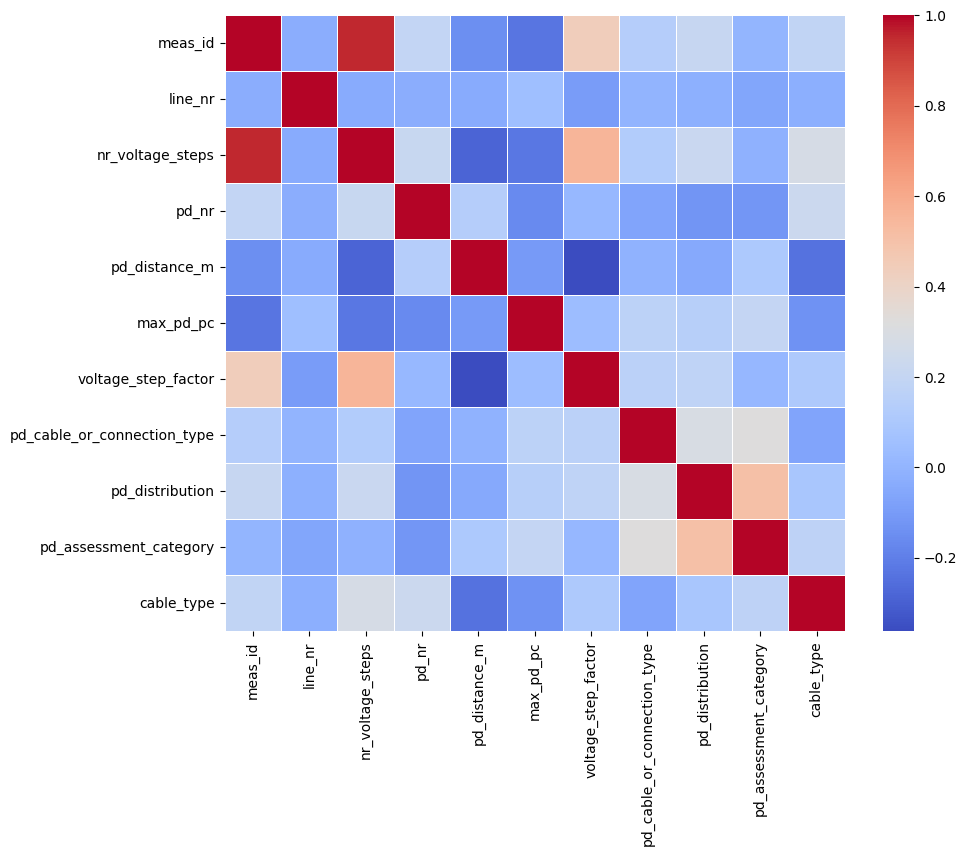

In [12]:
data_for_analysis = data.drop(['cable_id', 'plan_id', 'pd_id'], axis=1)
correlation_matrix = data_for_analysis.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

In [13]:
data_for_analysis

,meas_id,line_nr,nr_voltage_steps,pd_nr,pd_distance_m,max_pd_pc,voltage_step_factor,pd_cable_or_connection_type,pd_distribution,pd_assessment_category,cable_type
0,1,1,2,1,5063,850.0,1.8,2,4,4,2
1,2,1,2,1,5,620.0,1.7,1,3,1,1
2,2,1,2,4,212,820.0,1.7,1,3,1,1
3,2,1,2,2,55,580.0,1.7,1,0,1,1
4,2,1,2,3,143,520.0,1.7,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
371,206,2,8,5,185,2325.3,1.7,5,3,1,0
372,206,3,8,5,185,2531.3,1.7,5,3,1,0
373,207,1,8,6,350,2180.7,1.7,1,0,1,1
374,207,2,8,3,220,3010.5,1.7,5,0,1,1


In [14]:
data_for_analysis = data_for_analysis[(data_for_analysis['max_pd_pc'] != 43000) & (data_for_analysis['max_pd_pc'] != 46000)]
data_for_analysis = data_for_analysis[data_for_analysis['pd_distance_m'] != 5063]

In [15]:
# Column to group by but not use for training
group_column = 'meas_id'
groups = data_for_analysis['meas_id']

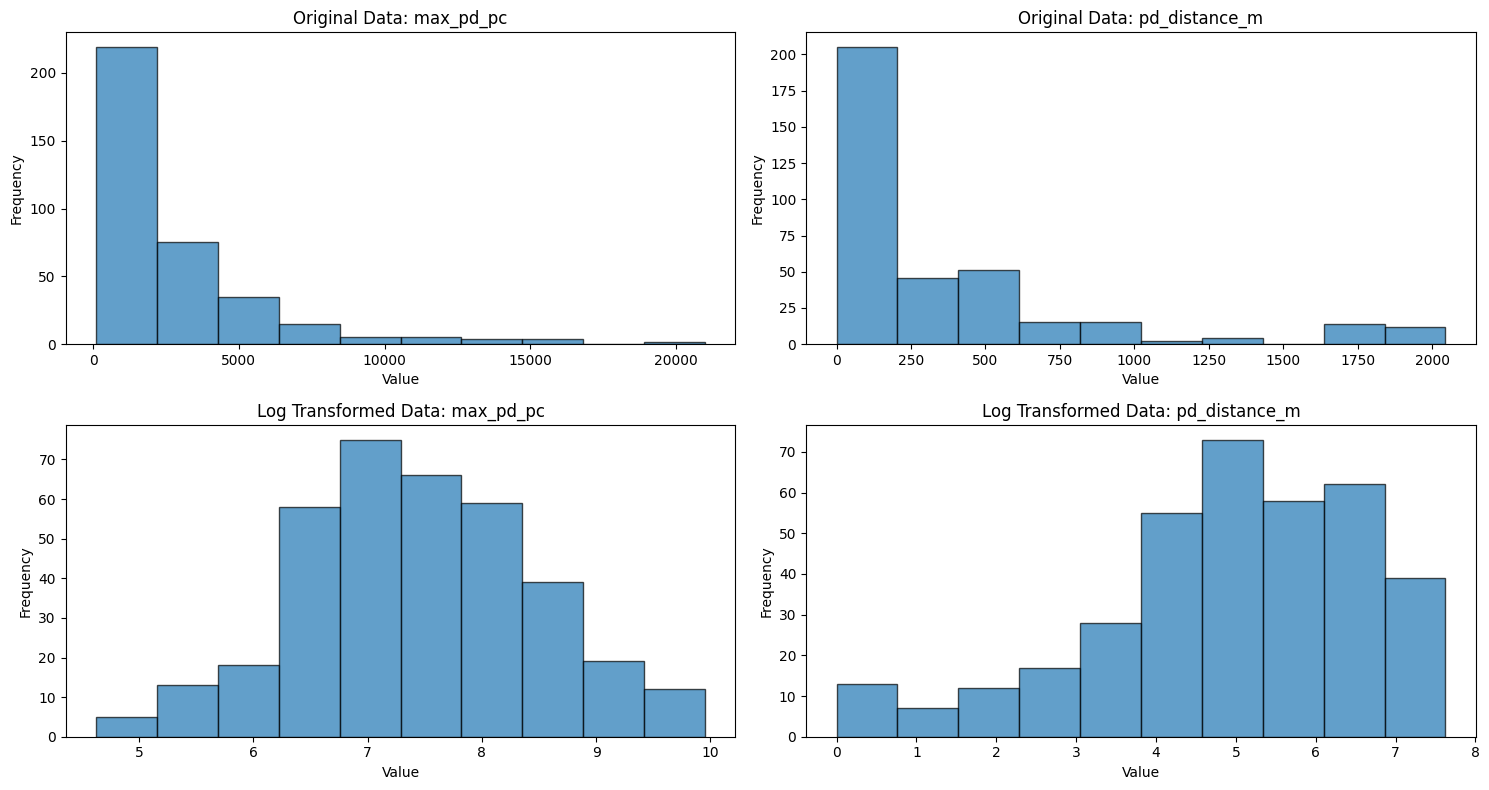

In [16]:
# Manually specify the numerical features
numerical_features = ['max_pd_pc', 'pd_distance_m']  # List of numerical columns to include
selected_data = data_for_analysis[numerical_features]

# Apply log transformation (add 1 to avoid log(0) issues)
log_transformed = selected_data.apply(lambda x: np.log1p(x))

# Plotting
fig, axes = plt.subplots(2, len(selected_data.columns), figsize=(15, 8))

# Titles for each transformation
titles = ["Original Data", "Log Transformed Data"]

# Loop through features and transformations
for i, col in enumerate(selected_data.columns):
    # Original Data
    axes[0, i].hist(selected_data[col], bins=10, edgecolor='k', alpha=0.7)
    axes[0, i].set_title(f"{titles[0]}: {col}")
    axes[0, i].set_xlabel("Value")
    axes[0, i].set_ylabel("Frequency")
    
    # Log Transformed Data
    axes[1, i].hist(log_transformed[col], bins=10, edgecolor='k', alpha=0.7)
    axes[1, i].set_title(f"{titles[1]}: {col}")
    axes[1, i].set_xlabel("Value")
    axes[1, i].set_ylabel("Frequency")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [17]:
data_for_analysis[numerical_features] = log_transformed

In [18]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column, group_column],axis=1)

In [19]:
# Standard deviation before scaling
x.std()

line_nr                        0.814994
nr_voltage_steps               3.013265
pd_nr                          1.484119
pd_distance_m                  1.693108
max_pd_pc                      1.004874
voltage_step_factor            0.233733
pd_cable_or_connection_type    0.990323
pd_distribution                1.541608
cable_type                     0.660661
dtype: float64

In [20]:
# apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
x_standardized = pd.DataFrame(scaled_features, columns=x.columns)

In [21]:
# standard deviation after scaling
x_standardized.std()

line_nr                        1.001376
nr_voltage_steps               1.001376
pd_nr                          1.001376
pd_distance_m                  1.001376
max_pd_pc                      1.001376
voltage_step_factor            1.001376
pd_cable_or_connection_type    1.001376
pd_distribution                1.001376
cable_type                     1.001376
dtype: float64

In [22]:
x_standardized.columns

Index(['line_nr', 'nr_voltage_steps', 'pd_nr', 'pd_distance_m', 'max_pd_pc',
       'voltage_step_factor', 'pd_cable_or_connection_type', 'pd_distribution',
       'cable_type'],
      dtype='object')

In [23]:
# Initialize GroupShuffleSplit
gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Split the data
train_idx, test_idx = next(gss.split(x_standardized, y, groups=groups))

# Create train and test sets
X_train, X_test = x_standardized.iloc[train_idx], x_standardized.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


### Encode step voltage
log transformation first and then do the std deviation

### Supervised Modelling

#### XGBoost

In [24]:
def xgboost_classifier(X, y, objective='multi:softmax', learning_rate=0.1, n_estimators=100):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create XGBClassifier with given parameters
    model = XGBClassifier(
        objective=objective,
        learning_rate=learning_rate,
        max_depth=4,
        n_estimators=n_estimators,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    ## Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=np.unique(y_test) + 1, 
            yticklabels=np.unique(y_test) + 1)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.8904
F1 Score: 0.8622


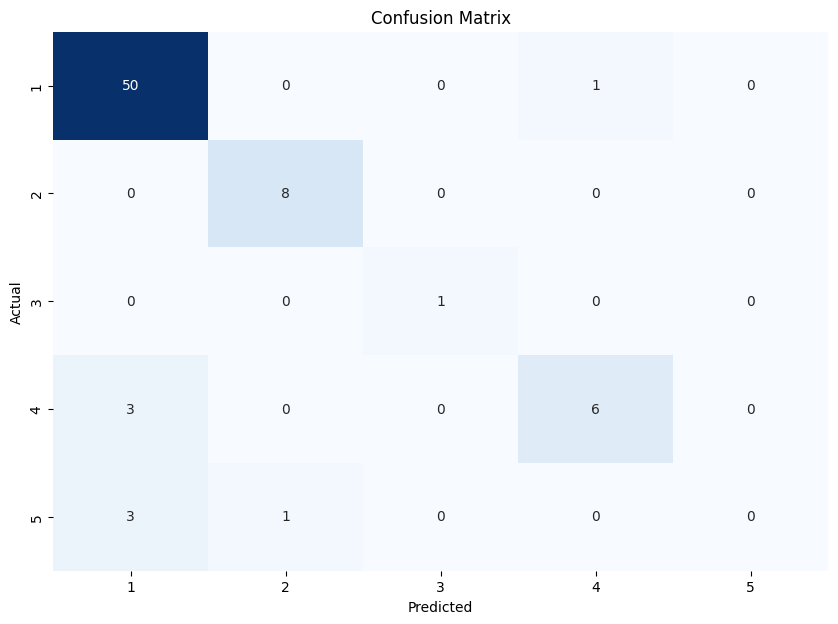

<Figure size 1000x600 with 0 Axes>

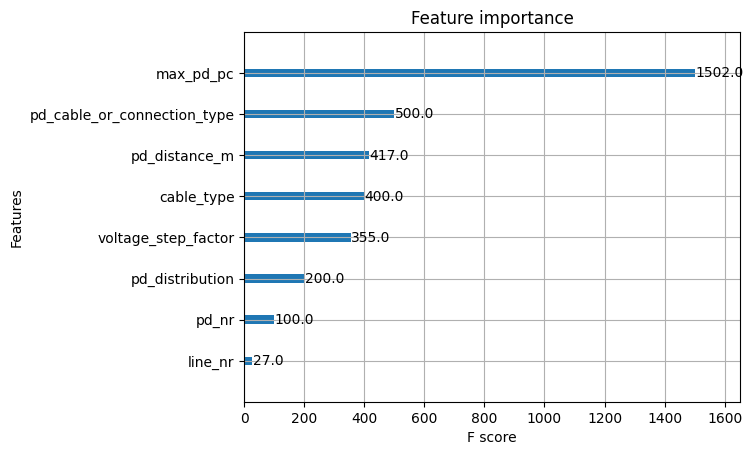

In [25]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = xgboost_classifier(x_standardized, y_adjusted, objective='multi:softmax', learning_rate=0.001, n_estimators=100)

# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(model)
plt.show()


In [26]:

def objective_xgb(trial, X_train, y_train, cv=3):
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, step=0.01)
    max_depth = trial.suggest_int('max_depth', 3, 6, step=1)
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=10)
    subsample = trial.suggest_float('subsample', 0.8, 1.0, step=0.1)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.1)
    gamma = trial.suggest_float('gamma', 0, 5, step=1)

    # Initialize model
    xgb = XGBClassifier(
        objective='multi:softmax',
        learning_rate=learning_rate,
        max_depth=max_depth,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        random_state=20,
        eval_metric='mlogloss',
        n_jobs=-1
    )

    # Cross-validation score (weighted F1-score)
    f1 = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1).mean()
    
    return f1

In [27]:
def xgboost_classifier_with_optuna(X, y, n_trials=30, cv=3):
    """Runs Optuna to optimize hyperparameters and train the best XGBoost model."""
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)
    
    # Create Optuna study
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective_xgb(trial, X_train, y_train, cv=cv), n_trials=n_trials)
    
    # Get best hyperparameters
    best_params = study.best_params
    print("Best Parameters:", best_params)
    
    # Train final model with best parameters
    best_model = XGBClassifier(**best_params, objective='multi:softmax', random_state=20, eval_metric='mlogloss', n_jobs=-1)
    best_model.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1 Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=np.unique(y_test), 
                yticklabels=np.unique(y_test))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    return best_model, best_params, accuracy, f1, cm

[I 2025-02-18 19:41:23,343] A new study created in memory with name: no-name-22c56204-b058-4a50-bac4-14c9507bb4a1
[I 2025-02-18 19:41:25,506] Trial 0 finished with value: 0.839743266157372 and parameters: {'learning_rate': 0.060000000000000005, 'max_depth': 6, 'n_estimators': 170, 'subsample': 1.0, 'colsample_bytree': 0.6, 'gamma': 4.0}. Best is trial 0 with value: 0.839743266157372.
[I 2025-02-18 19:41:25,990] Trial 1 finished with value: 0.8866110185107375 and parameters: {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.9, 'colsample_bytree': 0.9, 'gamma': 2.0}. Best is trial 1 with value: 0.8866110185107375.
[I 2025-02-18 19:41:26,016] Trial 2 finished with value: 0.9028648959450442 and parameters: {'learning_rate': 0.11, 'max_depth': 6, 'n_estimators': 50, 'subsample': 0.8, 'colsample_bytree': 0.5, 'gamma': 1.0}. Best is trial 2 with value: 0.9028648959450442.
[I 2025-02-18 19:41:26,482] Trial 3 finished with value: 0.941813878283341 and parameters: {'lea

Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 140, 'subsample': 1.0, 'colsample_bytree': 1.0, 'gamma': 0.0}
Test Accuracy: 0.9863
Test F1 Score: 0.9843


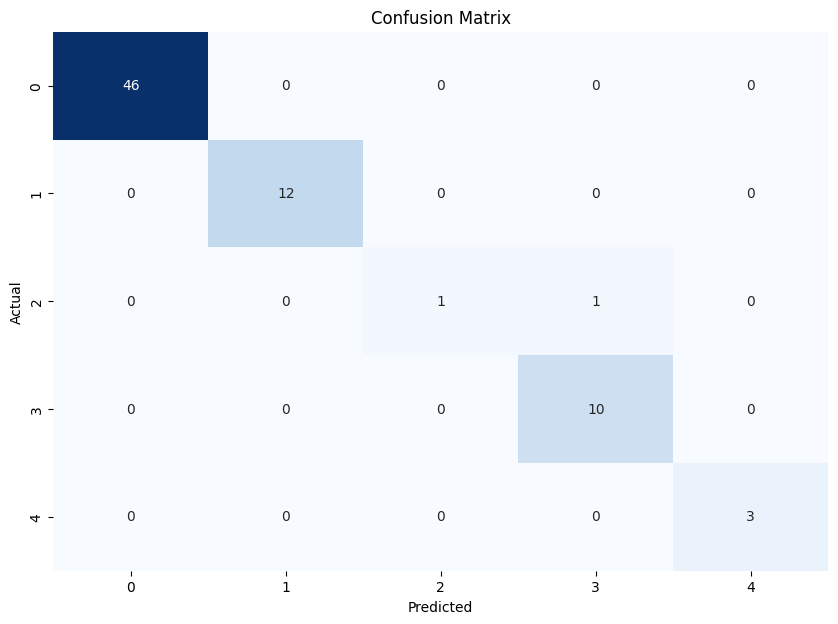

Optimal Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 140, 'subsample': 1.0, 'colsample_bytree': 1.0, 'gamma': 0.0}
Test Accuracy: 0.9863013698630136
F1 Score: 0.9843444227005871


In [28]:
best_model_xgb, best_params, accuracy, f1, cm = xgboost_classifier_with_optuna(x_standardized, y_adjusted, n_trials=30, cv=3)

# Results
print(f"Optimal Parameters: {best_params}")
print(f"Test Accuracy: {accuracy}")
print(f"F1 Score: {f1}")


#### Random Forest

In [29]:
def random_forest_classifier(X, y, n_estimators=100, criterion='gini'):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create RandomForestClassifier with given parameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=1,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=np.unique(y_test) + 1, 
            yticklabels=np.unique(y_test) + 1)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.9452
F1 Score: 0.9372


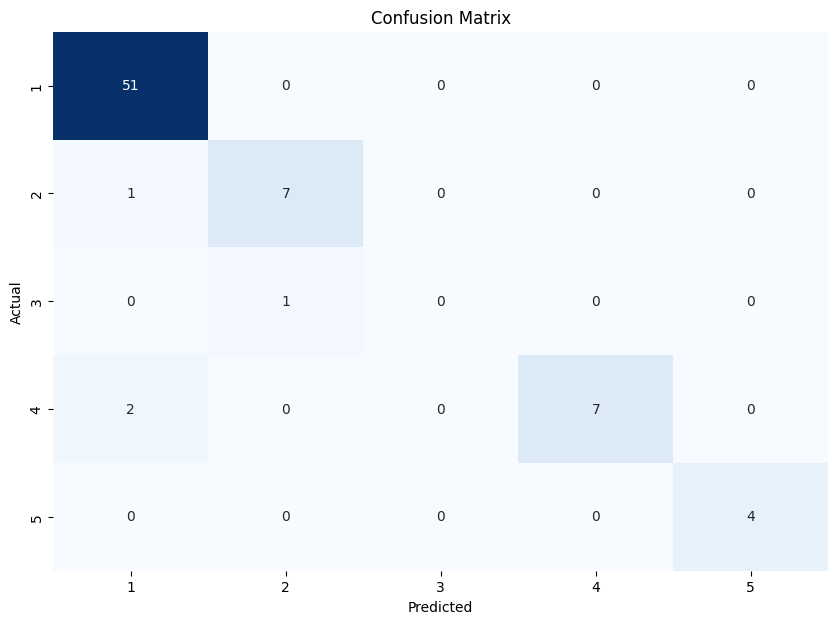

In [30]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = random_forest_classifier(x_standardized, y_adjusted, n_estimators=100, criterion='gini')


                       Feature  Importance
4                    max_pd_pc    0.273217
7              pd_distribution    0.204384
5          voltage_step_factor    0.160268
6  pd_cable_or_connection_type    0.155474
3                pd_distance_m    0.081509
1             nr_voltage_steps    0.046125
8                   cable_type    0.042038
2                        pd_nr    0.026328
0                      line_nr    0.010657


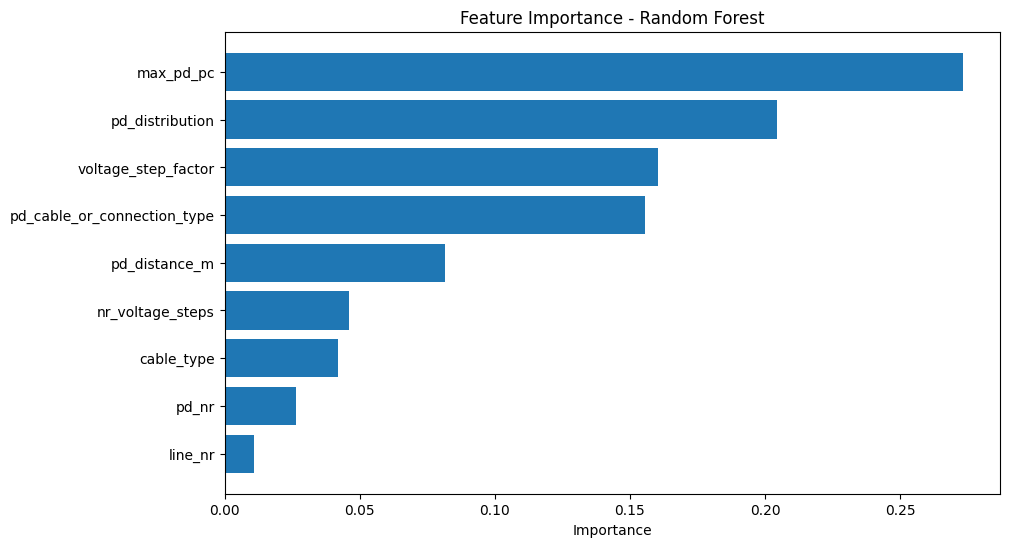

In [31]:
importance_scores = model.feature_importances_
# Create a DataFrame to sort the scores
feature_importance_df = pd.DataFrame({
    'Feature': x_standardized.columns,
    'Importance': importance_scores
})

# Sort the DataFrame by importance
sorted_features = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display sorted feature importance
print(sorted_features)

# Plot top 10 important features
plt.figure(figsize=(10, 6))
plt.barh(sorted_features['Feature'][:10][::-1], sorted_features['Importance'][:10][::-1])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

In [32]:
def objective_rf(trial, X_train, y_train):
    """Objective function for Optuna to optimize RandomForest hyperparameters."""
    
    # Define search space
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=10)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 5, 20, step=5)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10, step=1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4, step=1)

    # Initialize model
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=20,
        n_jobs=-1
    )

    # Cross-validation score (weighted F1-score)
    f1 = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1).mean()
    
    return f1  # Optuna tries to maximize this

In [33]:
def random_forest_classifier_with_optuna(X, y, n_trials=30):
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create Optuna study
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective_rf(trial, X_train, y_train), n_trials=n_trials)
    
    # Get best hyperparameters
    best_params = study.best_params
    print("Best Parameters:", best_params)
    
    # Train final model with best parameters
    best_model = RandomForestClassifier(**best_params, random_state=20, n_jobs=-1)
    best_model.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    return best_model, best_params, accuracy, f1, cm

[I 2025-02-18 19:41:30,342] A new study created in memory with name: no-name-63625e38-70a7-4278-9d72-38ee10794c53
[I 2025-02-18 19:41:30,710] Trial 0 finished with value: 0.9171324118647746 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.9171324118647746.
[I 2025-02-18 19:41:30,917] Trial 1 finished with value: 0.9248959782841826 and parameters: {'n_estimators': 110, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.9248959782841826.
[I 2025-02-18 19:41:31,157] Trial 2 finished with value: 0.9207593854808589 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.9248959782841826.
[I 2025-02-18 19:41:31,278] Trial 3 finished with value: 0.9297322852608694 and parameters: {'n_estimators': 80, 'criterion': 'entrop

Best Parameters: {'n_estimators': 170, 'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 1}
Accuracy: 0.9452
F1 Score: 0.9382


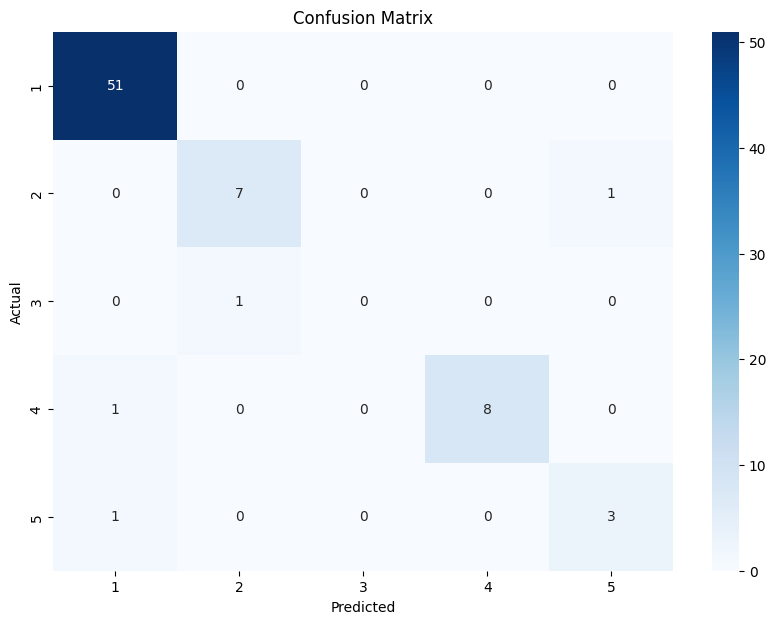

In [34]:
# Perform hyperparameter tuning and retrieve the best parameters
best_rf_model, best_rf_params, accuracy, f1, cm = random_forest_classifier_with_optuna(x_standardized, y)

#### KNN 

In [35]:
def knn_classifier(X, y, n_neighbors=5, metric='minkowski', p=2):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create KNN classifier with given parameters
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric,
        p=p
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


In [36]:
def knn_hyperparameter_tuning(X, y):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Define the parameter grid
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2]
    }
    
    # Create a KNN model
    knn = KNeighborsClassifier()
    
    # Perform GridSearchCV
    grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    # Best parameters and score
    print("Best Parameters:", grid_search.best_params_)
    print("Best Score:", grid_search.best_score_)
    
    return grid_search.best_estimator_


Accuracy: 0.9041
F1 Score: 0.8949


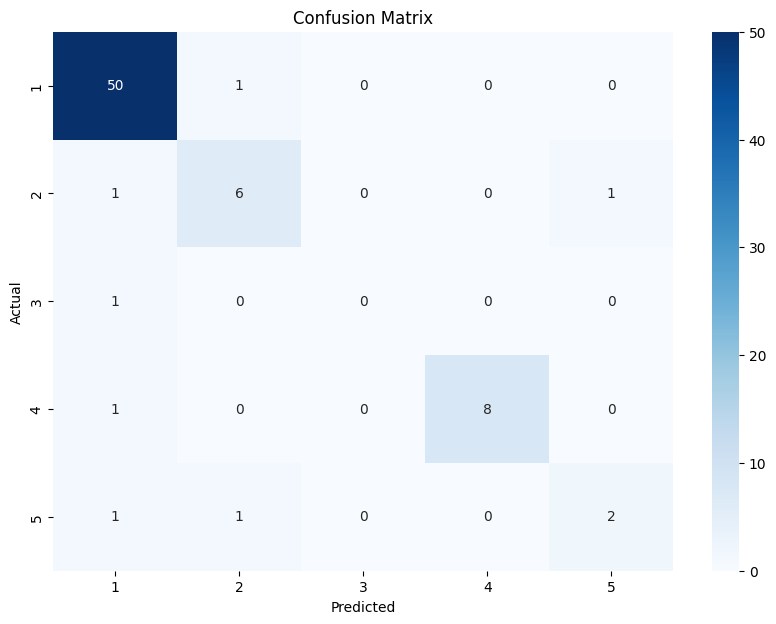

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1}
Best Score: 0.8866160140268848


In [37]:
model, acc, f1, cm = knn_classifier(x_standardized, y, n_neighbors=5, metric='minkowski', p=1)
knn_best_params = knn_hyperparameter_tuning(x_standardized, y)

#### Progressive Validation

In [40]:
def progressive_validation(model, X, y, groups):
    splits = [0.2, 0.4, 0.6, 0.8]
    results = []
    
    # Reset index to avoid mismatches
    X, y, groups = X.reset_index(drop=True), y.reset_index(drop=True), groups.reset_index(drop=True)
    sorted_indices = np.argsort(groups.to_numpy()) 
    X, y, groups = X.iloc[sorted_indices], y.iloc[sorted_indices], groups.iloc[sorted_indices]

    gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, test_idx in gss.split(X, y, groups=groups):
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]  
        break 

    unique_classes = set(y.unique())
    for split in splits:
        subset_idx = train_idx[:int(len(train_idx) * split)]
        X_train, y_train = X.iloc[subset_idx], y.iloc[subset_idx]
        missing_classes = unique_classes - set(y_train.unique())
        if missing_classes:
            print(f"Adding missing classes: {missing_classes}")
            for cls in missing_classes:
                cls_indices = y_test[y_test == cls].index
                if len(cls_indices) > 0:
                    add_idx = cls_indices[0] 
                    X_train = pd.concat([X_train, X.loc[[add_idx]]])
                    y_train = pd.concat([y_train, y.loc[[add_idx]]])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)

        results.append({
            'split': f'{int(split * 100)}% train / 20% test',
            'accuracy': accuracy,
            'f1_score': f1,
            'confusion_matrix': cm
        })

        # Plot confusion matrix
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {int(split * 100)}% Train / 20% Test")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        print(f"Results for {int(split * 100)}% train / 20% test:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print("-" * 40)
    
    return results

Adding missing classes: {np.int64(2), np.int64(4)}


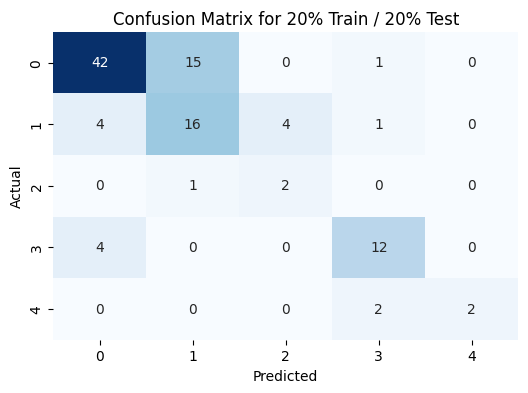

Results for 20% train / 20% test:
Accuracy: 0.6981
F1 Score: 0.7089
----------------------------------------
Adding missing classes: {np.int64(2), np.int64(4)}


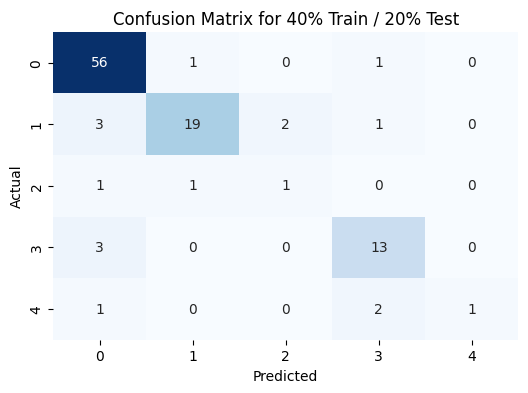

Results for 40% train / 20% test:
Accuracy: 0.8491
F1 Score: 0.8406
----------------------------------------
Adding missing classes: {np.int64(2)}


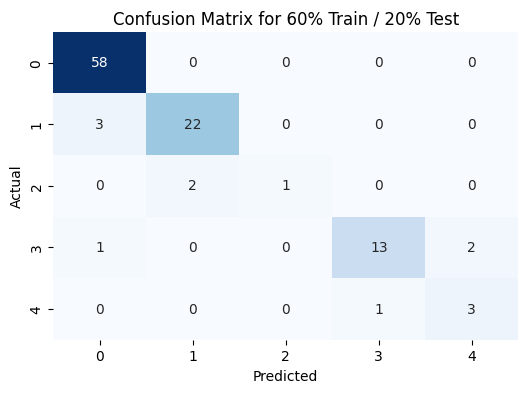

Results for 60% train / 20% test:
Accuracy: 0.9151
F1 Score: 0.9108
----------------------------------------


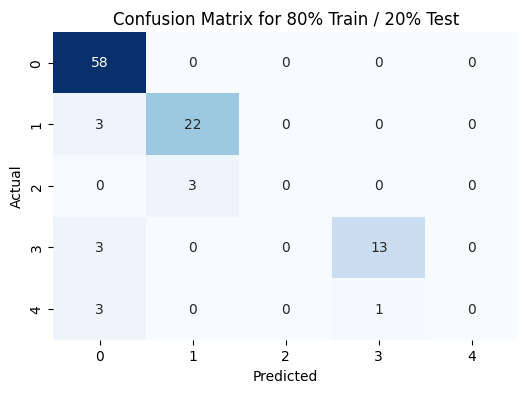

Results for 80% train / 20% test:
Accuracy: 0.8774
F1 Score: 0.8461
----------------------------------------
XGBoost Results:
{'split': '20% train / 20% test', 'accuracy': 0.6981132075471698, 'f1_score': np.float64(0.7089264040604658), 'confusion_matrix': array([[42, 15,  0,  1,  0],
       [ 4, 16,  4,  1,  0],
       [ 0,  1,  2,  0,  0],
       [ 4,  0,  0, 12,  0],
       [ 0,  0,  0,  2,  2]])}
{'split': '40% train / 20% test', 'accuracy': 0.8490566037735849, 'f1_score': np.float64(0.8406050580985692), 'confusion_matrix': array([[56,  1,  0,  1,  0],
       [ 3, 19,  2,  1,  0],
       [ 1,  1,  1,  0,  0],
       [ 3,  0,  0, 13,  0],
       [ 1,  0,  0,  2,  1]])}
{'split': '60% train / 20% test', 'accuracy': 0.9150943396226415, 'f1_score': np.float64(0.9108394301116675), 'confusion_matrix': array([[58,  0,  0,  0,  0],
       [ 3, 22,  0,  0,  0],
       [ 0,  2,  1,  0,  0],
       [ 1,  0,  0, 13,  2],
       [ 0,  0,  0,  1,  3]])}
{'split': '80% train / 20% test', 'accuracy

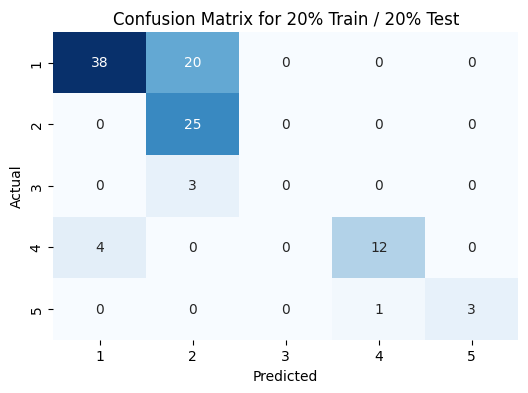

Results for 20% train / 20% test:
Accuracy: 0.7358
F1 Score: 0.7347
----------------------------------------
Adding missing classes: {np.int64(3), np.int64(5)}


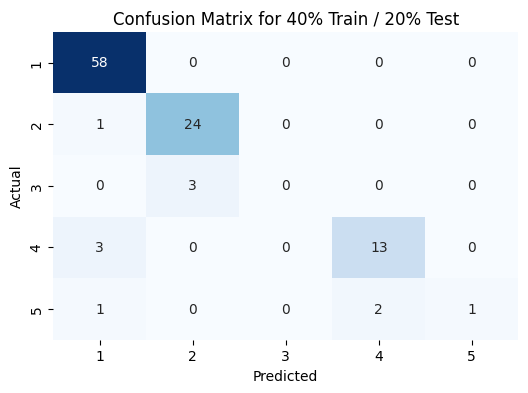

Results for 40% train / 20% test:
Accuracy: 0.9057
F1 Score: 0.8840
----------------------------------------
Adding missing classes: {np.int64(3)}


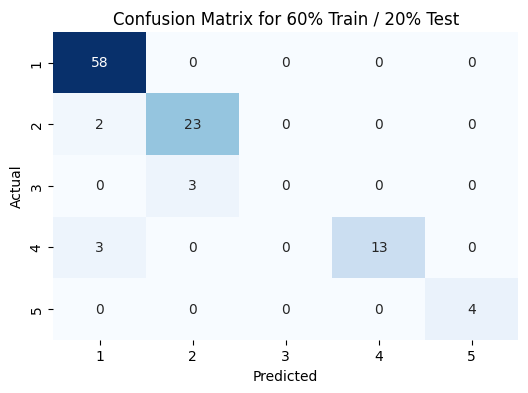

Results for 60% train / 20% test:
Accuracy: 0.9245
F1 Score: 0.9104
----------------------------------------


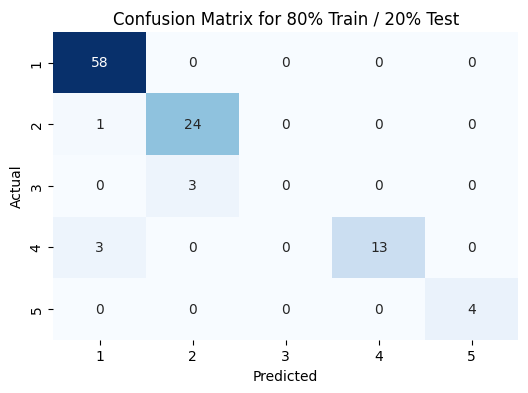

Results for 80% train / 20% test:
Accuracy: 0.9340
F1 Score: 0.9197
----------------------------------------
Random Forest Results:
{'split': '20% train / 20% test', 'accuracy': 0.7358490566037735, 'f1_score': np.float64(0.7346531925485766), 'confusion_matrix': array([[38, 20,  0,  0,  0],
       [ 0, 25,  0,  0,  0],
       [ 0,  3,  0,  0,  0],
       [ 4,  0,  0, 12,  0],
       [ 0,  0,  0,  1,  3]])}
{'split': '40% train / 20% test', 'accuracy': 0.9056603773584906, 'f1_score': np.float64(0.8839583367995917), 'confusion_matrix': array([[58,  0,  0,  0,  0],
       [ 1, 24,  0,  0,  0],
       [ 0,  3,  0,  0,  0],
       [ 3,  0,  0, 13,  0],
       [ 1,  0,  0,  2,  1]])}
{'split': '60% train / 20% test', 'accuracy': 0.9245283018867925, 'f1_score': np.float64(0.9103504998035284), 'confusion_matrix': array([[58,  0,  0,  0,  0],
       [ 2, 23,  0,  0,  0],
       [ 0,  3,  0,  0,  0],
       [ 3,  0,  0, 13,  0],
       [ 0,  0,  0,  0,  4]])}
{'split': '80% train / 20% test', 'ac

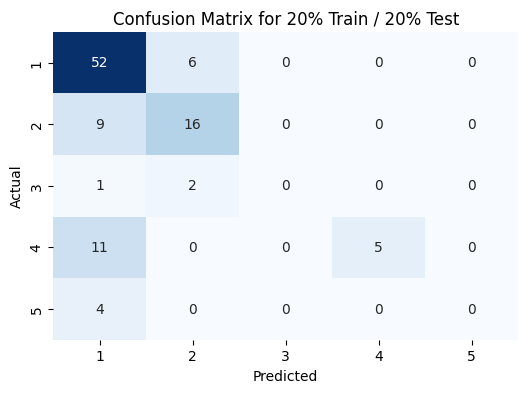

Results for 20% train / 20% test:
Accuracy: 0.6887
F1 Score: 0.6474
----------------------------------------
Adding missing classes: {np.int64(3), np.int64(5)}


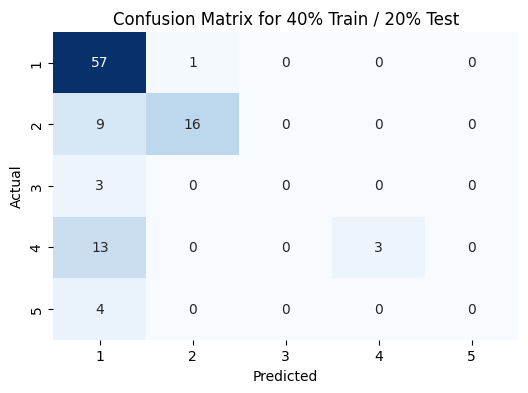

Results for 40% train / 20% test:
Accuracy: 0.7170
F1 Score: 0.6605
----------------------------------------
Adding missing classes: {np.int64(3)}


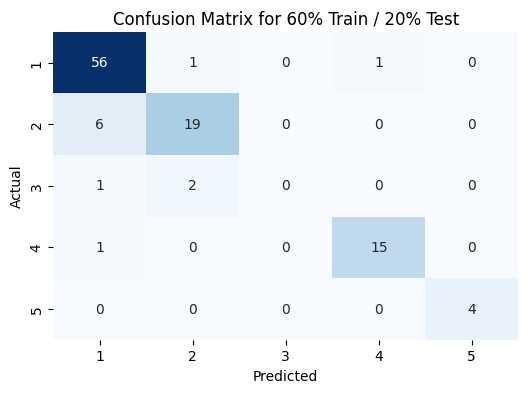

Results for 60% train / 20% test:
Accuracy: 0.8868
F1 Score: 0.8723
----------------------------------------


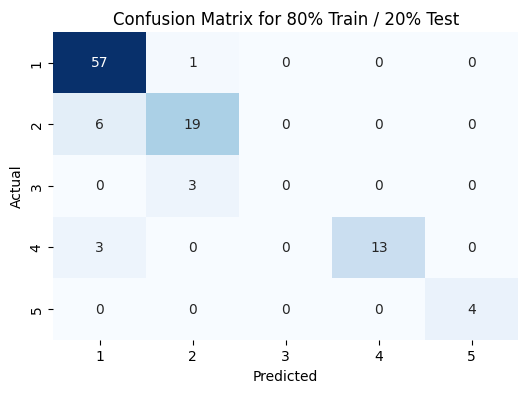

Results for 80% train / 20% test:
Accuracy: 0.8774
F1 Score: 0.8628
----------------------------------------


[{'split': '20% train / 20% test',
  'accuracy': 0.6886792452830188,
  'f1_score': np.float64(0.6474250916299434),
  'confusion_matrix': array([[52,  6,  0,  0,  0],
         [ 9, 16,  0,  0,  0],
         [ 1,  2,  0,  0,  0],
         [11,  0,  0,  5,  0],
         [ 4,  0,  0,  0,  0]])},
 {'split': '40% train / 20% test',
  'accuracy': 0.7169811320754716,
  'f1_score': np.float64(0.6605369555965385),
  'confusion_matrix': array([[57,  1,  0,  0,  0],
         [ 9, 16,  0,  0,  0],
         [ 3,  0,  0,  0,  0],
         [13,  0,  0,  3,  0],
         [ 4,  0,  0,  0,  0]])},
 {'split': '60% train / 20% test',
  'accuracy': 0.8867924528301887,
  'f1_score': np.float64(0.8722515811018025),
  'confusion_matrix': array([[56,  1,  0,  1,  0],
         [ 6, 19,  0,  0,  0],
         [ 1,  2,  0,  0,  0],
         [ 1,  0,  0, 15,  0],
         [ 0,  0,  0,  0,  4]])},
 {'split': '80% train / 20% test',
  'accuracy': 0.8773584905660378,
  'f1_score': np.float64(0.8628214613022156),
  'con

In [41]:
# Run progressive validation
progressive_results_xgb = progressive_validation(best_model_xgb, x_standardized, pd.Series(y_adjusted), groups)
print("XGBoost Results:")
# Print final results
for result in progressive_results_xgb:
    print(result)

# Run progressive validation
progressive_results_rf = progressive_validation(best_rf_model, x_standardized, y, groups)
print("Random Forest Results:")
# Print final results
for result in progressive_results_rf:
    print(result)

# KNN Model
tuned_knn_model = KNeighborsClassifier(**knn_best_params.get_params())
print("KNN Results:")
progressive_validation(tuned_knn_model, x_standardized, y, groups)